In [2]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Parámetros del algoritmo genético
Nind = 100       # número de individuos
Pc = 0.9         # probabilidad de cruza
Pm = 0.01        # probabilidad de mutación
Maxgen = 1000    # número máximo de generaciones
precision = 4    # 4 decimales


rango = np.array([
    [-3.0, 12.1],   # x
    [ 4.1,  5.8]    # y
])

# Calcular cuántos bits necesita cada variable
def calcular_bits_por_variable(rango, precision=4):
    bits = []
    for minimo, maximo in rango:
        cantidad_valores = (maximo - minimo) * (10**precision) + 1
        bits.append(int(np.ceil(np.log2(cantidad_valores))))
    return bits

bits_por_var = calcular_bits_por_variable(rango, precision)
Lind = sum(bits_por_var)

print("Bits por variable:", bits_por_var)   
print("Longitud total del individuo (Lind):", Lind)  

Bits por variable: [18, 15]
Longitud total del individuo (Lind): 33


In [4]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind), dtype=int)


def decodifica(genotipo, rango, bits_por_var, precision=4):
    Nind = genotipo.shape[0]
    Nvar = len(bits_por_var)
    fenotipo = np.zeros((Nind, Nvar), dtype=float)

    inicio = 0
    for j, nbits in enumerate(bits_por_var):
        fin = inicio + nbits
        subcadena = genotipo[:, inicio:fin]

        # Conversión binario a decimal
        pesos = 2 ** np.arange(nbits - 1, -1, -1)
        decimal = subcadena @ pesos

        minimo, maximo = rango[j]
        fenotipo[:, j] = minimo + decimal * (maximo - minimo) / (2**nbits - 1)

        inicio = fin

    return np.round(fenotipo, precision)


def objfun(fenotipo):
    x = fenotipo[:, 0]
    y = fenotipo[:, 1]
    objv = 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)
    return objv.reshape(-1, 1)


def rankeo(objv, direccion=1, SP=2):
    valores = objv.ravel()
    Nind = len(valores)
    aptitud = np.zeros(Nind, dtype=float)

    if direccion == 1:
        # Maximización: ordenar de menor a mayor
        orden = np.argsort(valores)
    else:
        # Minimización
        orden = np.argsort(-valores)

    ranks = np.arange(Nind)
    apt = 2 - SP + 2 * (SP - 1) * (ranks / (Nind - 1))
    aptitud[orden] = apt

    return aptitud.reshape(-1, 1)


def ruleta(genotipo, aptitud):
    prob = aptitud.ravel() / aptitud.sum()
    acumulada = np.cumsum(prob)

    r = np.random.rand(genotipo.shape[0])
    idx = np.searchsorted(acumulada, r)

    return genotipo[idx, :].copy()


def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)

            hijo1 = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            hijo2 = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))

            aux_gen[i, :] = hijo1
            aux_gen[i + 1, :] = hijo2

    return aux_gen


def muta(nuevo_gen, Pm):
    mascara = np.random.rand(*nuevo_gen.shape) <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

In [6]:
# Crear población inicial
genotipo = creapob(Nind, Lind)

# Históricos
mejor_hist = np.zeros(Maxgen)
mejor_xy_hist = np.zeros((Maxgen, 2))
mejor_cromosoma_hist = np.zeros((Maxgen, Lind), dtype=int)

# Ciclo evolutivo
for gen in range(Maxgen):
    fenotipo = decodifica(genotipo, rango, bits_por_var, precision)
    objv = objfun(fenotipo)

    idx = np.argmax(objv)
    mejor_hist[gen] = objv[idx, 0]
    mejor_xy_hist[gen, :] = fenotipo[idx, :]
    mejor_cromosoma_hist[gen, :] = genotipo[idx, :]

    if gen < Maxgen - 1:
        aptitud = rankeo(objv, direccion=1)
        nuevo_gen = ruleta(genotipo, aptitud)
        nuevo_gen = xunpunto(nuevo_gen, Pc)
        nuevo_gen = muta(nuevo_gen, Pm)
        genotipo = nuevo_gen

# Mejor resultado global
idx_global = np.argmax(mejor_hist)
mejor_valor = mejor_hist[idx_global]
mejor_x, mejor_y = mejor_xy_hist[idx_global]
mejor_cromosoma = mejor_cromosoma_hist[idx_global]

print("===== MEJOR SOLUCIÓN ENCONTRADA =====")
print(f"Generación donde apareció: {idx_global}")
print(f"x = {mejor_x}")
print(f"y = {mejor_y}")
print(f"f(x, y) = {mejor_valor}")
print("Cromosoma:")
print(mejor_cromosoma)

===== MEJOR SOLUCIÓN ENCONTRADA =====
Generación donde apareció: 62
x = 11.6255
y = 5.725
f(x, y) = 38.850270522583024
Cromosoma:
[1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1]


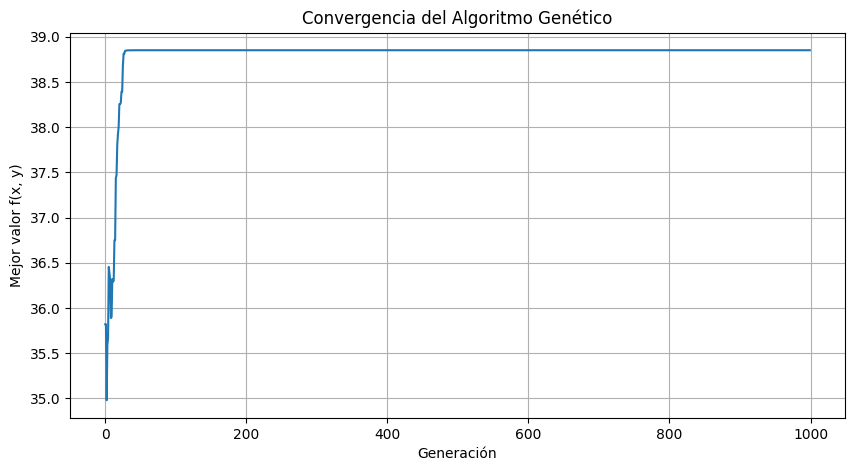

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(mejor_hist)
plt.xlabel("Generación")
plt.ylabel("Mejor valor f(x, y)")
plt.title("Convergencia del Algoritmo Genético")
plt.grid(True)
plt.show()

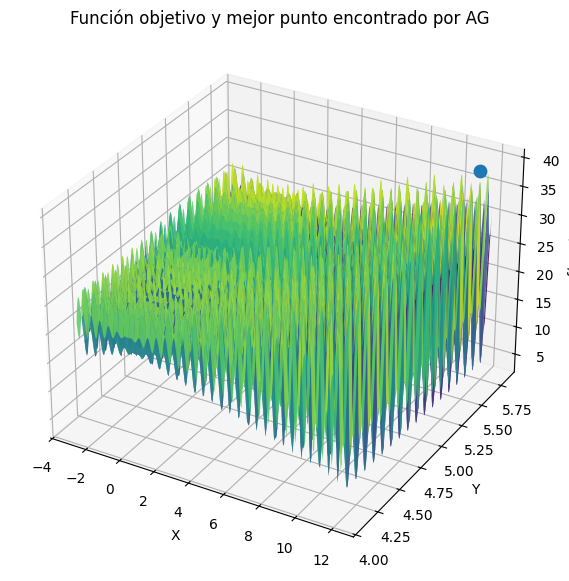

Mejor punto AG: x = 11.6255, y = 5.725, f(x,y) = 38.850270522583024


In [10]:
def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

x = np.linspace(-3, 12.1, 250)
y = np.linspace(4.1, 5.8, 250)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)
ax.scatter(mejor_x, mejor_y, mejor_valor, s=80)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Función objetivo y mejor punto encontrado por AG')

plt.show()

print(f"Mejor punto AG: x = {mejor_x}, y = {mejor_y}, f(x,y) = {mejor_valor}")

# PROGRAMACIÓN ESTRUCTURADA SIN AG

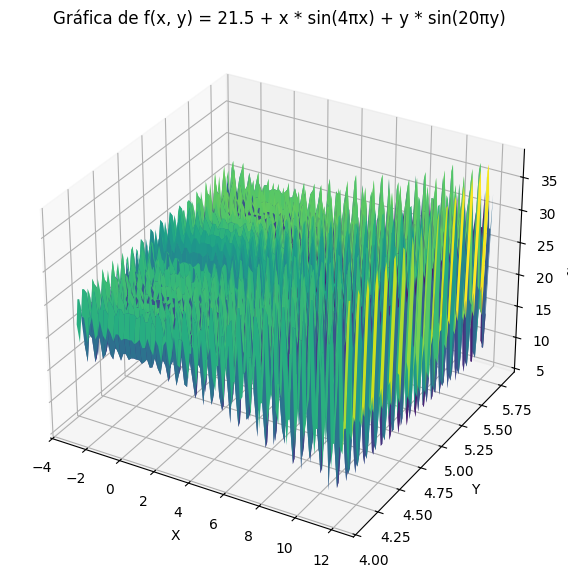

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

x = np.linspace(-3, 12.1, 100)
y = np.linspace(4.1, 5.8, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gráfica de f(x, y) = 21.5 + x * sin(4πx) + y * sin(20πy)')

plt.show()

# EJERCICIO AGS PDF
# VICTOR CEN

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parámetros del ejercicio
Nind = 5          # tamaño de la población
Lind = 3          # 3 bits
Pc = 0.70         # probabilidad de cruza
Pm = 1/15         # probabilidad de mutación
Maxgen = 100      # número de generaciones

rango = np.array([[0.0, 0.875]])

In [4]:
def f(x):
    u = (11/2) * x - (7/2)
    return (1 - u**2) * (np.cos(u) + 1) + 2

In [6]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind), dtype=int)


def decodifica(genotipo, rango):
    Nind, Lind = genotipo.shape
    pesos = 2 ** np.arange(Lind - 1, -1, -1)   # [4,2,1]
    decimal = genotipo @ pesos

    xmin, xmax = rango[0]
    x = xmin + decimal * (xmax - xmin) / (2**Lind - 1)

    return x.reshape(-1, 1)


def objfun(fenotipo):
    x = fenotipo[:, 0]
    return f(x).reshape(-1, 1)


def fitness_proporcional(objv):
    return objv.copy()


def ruleta(genotipo, fitness):
    Nind = genotipo.shape[0]
    prob = fitness.ravel() / np.sum(fitness)
    acumulada = np.cumsum(prob)

    r = np.random.rand(Nind)
    idx = np.searchsorted(acumulada, r)

    return genotipo[idx, :].copy()


def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)  # entre 1 y Lind-1
            hijo1 = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i+1, corte:]))
            hijo2 = np.concatenate((nuevo_gen[i+1, :corte], nuevo_gen[i, corte:]))

            aux_gen[i, :] = hijo1
            aux_gen[i+1, :] = hijo2

    return aux_gen


def muta(nuevo_gen, Pm):
    mascara = np.random.rand(*nuevo_gen.shape) <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

In [8]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv = objfun(fenotipo)

print("Población inicial")
print("Ind | Código | x | f(x)")
for i in range(Nind):
    codigo = ''.join(map(str, genotipo[i]))
    print(f"{i:>3} |  {codigo}  | {fenotipo[i,0]:.3f} | {objv[i,0]:.3f}")

Población inicial
Ind | Código | x | f(x)
  0 |  010  | 0.250 | 0.335
  1 |  001  | 0.125 | 1.629
  2 |  000  | 0.000 | 1.285
  3 |  100  | 0.500 | 2.758
  4 |  001  | 0.125 | 1.629


In [10]:
# Históricos
mejor_hist = np.zeros(Maxgen)
mejor_x_hist = np.zeros(Maxgen)
mejor_cromosoma_hist = np.zeros((Maxgen, Lind), dtype=int)

for gen in range(Maxgen):
    fenotipo = decodifica(genotipo, rango)
    objv = objfun(fenotipo)

    # Guardar el mejor de la generación
    idx = np.argmax(objv)
    mejor_hist[gen] = objv[idx, 0]
    mejor_x_hist[gen] = fenotipo[idx, 0]
    mejor_cromosoma_hist[gen, :] = genotipo[idx, :]

    # Evolución
    if gen < Maxgen - 1:
        fitness = fitness_proporcional(objv)
        nuevo_gen = ruleta(genotipo, fitness)
        nuevo_gen = xunpunto(nuevo_gen, Pc)
        nuevo_gen = muta(nuevo_gen, Pm)
        genotipo = nuevo_gen

# Mejor solución global
idx_global = np.argmax(mejor_hist)
mejor_valor = mejor_hist[idx_global]
mejor_x = mejor_x_hist[idx_global]
mejor_cromosoma = mejor_cromosoma_hist[idx_global]

print("===== MEJOR SOLUCIÓN ENCONTRADA =====")
print(f"Generación: {idx_global}")
print(f"Cromosoma: {''.join(map(str, mejor_cromosoma))}")
print(f"x = {mejor_x:.3f}")
print(f"f(x) = {mejor_valor:.3f}")

===== MEJOR SOLUCIÓN ENCONTRADA =====
Generación: 1
Cromosoma: 101
x = 0.625
f(x) = 3.990


In [12]:
fenotipo_final = decodifica(genotipo, rango)
objv_final = objfun(fenotipo_final)

print("Última población")
print("Ind | Código | x | f(x)")
for i in range(Nind):
    codigo = ''.join(map(str, genotipo[i]))
    print(f"{i:>3} |  {codigo}  | {fenotipo_final[i,0]:.3f} | {objv_final[i,0]:.3f}")

Última población
Ind | Código | x | f(x)
  0 |  100  | 0.500 | 2.758
  1 |  101  | 0.625 | 3.990
  2 |  100  | 0.500 | 2.758
  3 |  001  | 0.125 | 1.629
  4 |  101  | 0.625 | 3.990


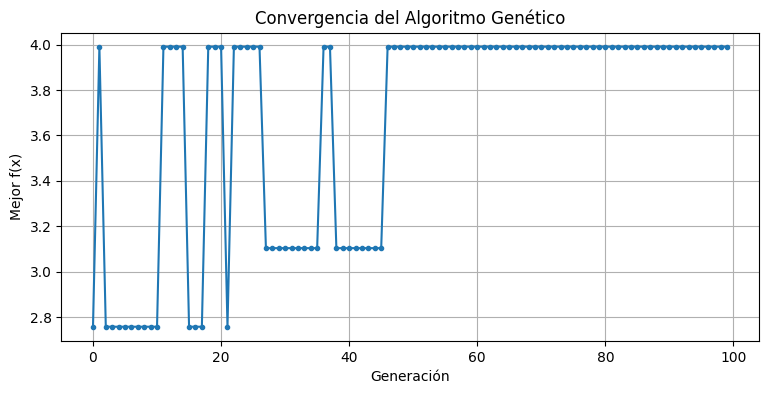

In [14]:
plt.figure(figsize=(9, 4))
plt.plot(mejor_hist, marker='o', markersize=3)
plt.xlabel("Generación")
plt.ylabel("Mejor f(x)")
plt.title("Convergencia del Algoritmo Genético")
plt.grid(True)
plt.show()

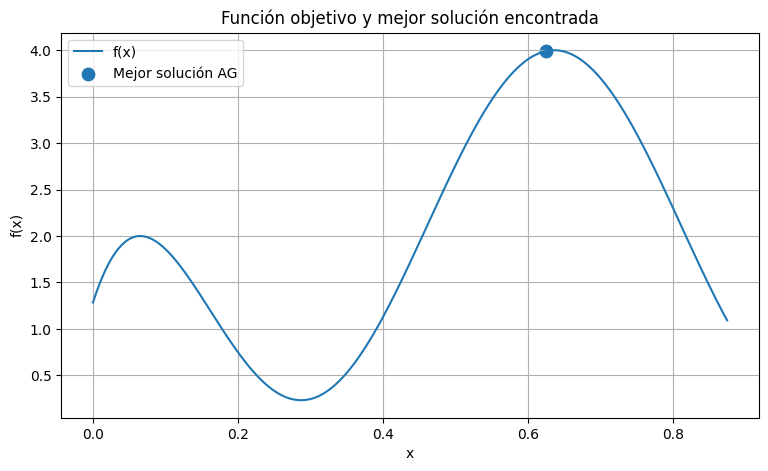

In [16]:
x_plot = np.linspace(0, 0.875, 400)
y_plot = f(x_plot)

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, label="f(x)")
plt.scatter(mejor_x, mejor_valor, s=80, label="Mejor solución AG")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función objetivo y mejor solución encontrada")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
fenotipo_aux = decodifica(genotipo, rango)
objv_aux = objfun(fenotipo_aux)
fitness_aux = fitness_proporcional(objv_aux)

prob = fitness_aux.ravel() / np.sum(fitness_aux)
acum = np.cumsum(prob)

print("Ind | Código | x | f(x) | Probabilidad | Acumulada")
for i in range(Nind):
    codigo = ''.join(map(str, genotipo[i]))
    print(f"{i:>3} |  {codigo}  | {fenotipo_aux[i,0]:.3f} | {objv_aux[i,0]:.3f} | {prob[i]:.6f} | {acum[i]:.6f}")

Ind | Código | x | f(x) | Probabilidad | Acumulada
  0 |  100  | 0.500 | 2.758 | 0.182323 | 0.182323
  1 |  101  | 0.625 | 3.990 | 0.263820 | 0.446143
  2 |  100  | 0.500 | 2.758 | 0.182323 | 0.628466
  3 |  001  | 0.125 | 1.629 | 0.107715 | 0.736180
  4 |  101  | 0.625 | 3.990 | 0.263820 | 1.000000
